## Implementation of Linear regression using python

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [4]:
df_food = pd.read_csv('Food_Delivery_Times.csv')
df_wh = pd.read_csv('weight-height.csv')


In [5]:
print(df_food.head())
print(df_wh.head())


   Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0       522         7.93   Windy           Low   Afternoon      Scooter   
1       738        16.42   Clear        Medium     Evening         Bike   
2       741         9.52   Foggy           Low       Night      Scooter   
3       661         7.44   Rainy        Medium   Afternoon      Scooter   
4       412        19.03   Clear           Low     Morning         Bike   

   Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
0                    12                     1.0                 43  
1                    20                     2.0                 84  
2                    28                     1.0                 59  
3                     5                     1.0                 37  
4                    16                     5.0                 68  
  Gender     Height      Weight
0   Male  73.847017  241.893563
1   Male  68.781904  162.310473
2   Male  74.110105  212.740856
3   Mal

In [6]:
df_wh = pd.read_csv('weight-height.csv')
print(df_wh.head())
print(df_wh.info())
print(df_wh.describe())


  Gender     Height      Weight
0   Male  73.847017  241.893563
1   Male  68.781904  162.310473
2   Male  74.110105  212.740856
3   Male  71.730978  220.042470
4   Male  69.881796  206.349801
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Gender  10000 non-null  object 
 1   Height  10000 non-null  float64
 2   Weight  10000 non-null  float64
dtypes: float64(2), object(1)
memory usage: 234.5+ KB
None
             Height        Weight
count  10000.000000  10000.000000
mean      66.397560    161.440357
std        4.237001     32.108439
min       54.263133     64.700127
25%       63.505620    135.818051
50%       66.319161    161.212928
75%       69.179914    187.169525
max      172.800844    269.989698


In [7]:
X = df_wh[['Height']]   # input
y = df_wh['Weight']     # output


In [ ]:
### import required libraries
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [10]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [11]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [12]:
y_pred = model.predict(X_test)


In [13]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("Mean Squared Error:", mse)
print("R2 Score:", r2)


Mean Squared Error: 647.6942257374137
R2 Score: 0.3815829595234297


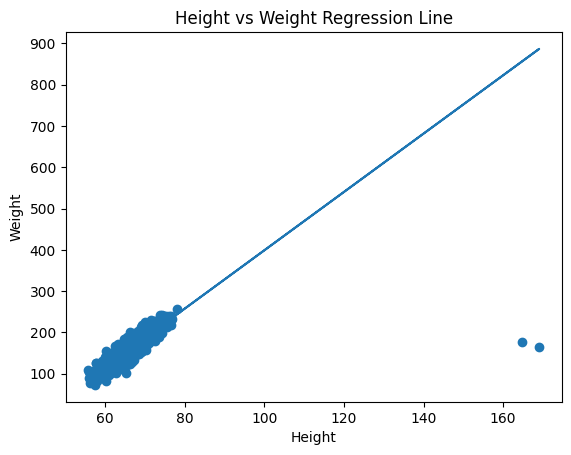

In [14]:
plt.scatter(X_test, y_test)
plt.plot(X_test, y_pred)
plt.xlabel('Height')
plt.ylabel('Weight')
plt.title('Height vs Weight Regression Line')
plt.show()


In [15]:
df_food.head()


,Order_ID,Distance_km,Weather,Traffic_Level,Time_of_Day,Vehicle_Type,Preparation_Time_min,Courier_Experience_yrs,Delivery_Time_min
0,522,7.93,Windy,Low,Afternoon,Scooter,12,1.0,43
1,738,16.42,Clear,Medium,Evening,Bike,20,2.0,84
2,741,9.52,Foggy,Low,Night,Scooter,28,1.0,59
3,661,7.44,Rainy,Medium,Afternoon,Scooter,5,1.0,37
4,412,19.03,Clear,Low,Morning,Bike,16,5.0,68


In [16]:
df_food = pd.read_csv('Food_Delivery_Times.csv')
print(df_food.head())
print(df_food.info())
print(df_food.describe())


   Order_ID  Distance_km Weather Traffic_Level Time_of_Day Vehicle_Type  \
0       522         7.93   Windy           Low   Afternoon      Scooter   
1       738        16.42   Clear        Medium     Evening         Bike   
2       741         9.52   Foggy           Low       Night      Scooter   
3       661         7.44   Rainy        Medium   Afternoon      Scooter   
4       412        19.03   Clear           Low     Morning         Bike   

   Preparation_Time_min  Courier_Experience_yrs  Delivery_Time_min  
0                    12                     1.0                 43  
1                    20                     2.0                 84  
2                    28                     1.0                 59  
3                     5                     1.0                 37  
4                    16                     5.0                 68  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                  N

In [17]:
X = df_food[['Distance_km', 'Weather', 'Traffic_Level', 'Time_of_Day',
             'Vehicle_Type', 'Preparation_Time_min', 'Courier_Experience_yrs']]

y = df_food['Delivery_Time_min']


In [18]:
X = pd.get_dummies(X, drop_first=True)


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)


In [21]:
from sklearn.linear_model import LinearRegression
from sklearn.impute import SimpleImputer

# Impute missing values in X_train and X_test
imputer_numeric = SimpleImputer(strategy='mean')
imputer_categorical = SimpleImputer(strategy='most_frequent')

# Identify numerical and categorical columns
numeric_cols = X_train.select_dtypes(include=np.number).columns
categorical_cols = X_train.select_dtypes(include='object').columns


X_train[numeric_cols] = imputer_numeric.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = imputer_numeric.transform(X_test[numeric_cols])

# Impute categorical columns if they exist after one-hot encoding (they won't in this case as get_dummies creates numeric)
# However, for robustness, I'll include the imputation for categorical columns in case the approach changes.
# Note: After pd.get_dummies, all columns will be numeric (int or float), so this part might not be strictly necessary
# depending on the exact dtypes after get_dummies and before imputation.
# Let's re-check dtypes after get_dummies but before this cell if necessary.
# For now, assuming get_dummies outputs numeric-compatible dtypes for imputation:
for col in categorical_cols:
    X_train[col] = imputer_categorical.fit_transform(X_train[[col]])
    X_test[col] = imputer_categorical.transform(X_test[[col]])


model_food = LinearRegression()
model_food.fit(X_train, y_train)

LinearRegression()

In [22]:
y_pred_food = model_food.predict(X_test)


In [23]:
from sklearn.metrics import mean_squared_error, r2_score

mse_food = mean_squared_error(y_test, y_pred_food)
r2_food = r2_score(y_test, y_pred_food)

print("Mean Squared Error:", mse_food)
print("R2 Score:", r2_food)


Mean Squared Error: 79.23829112470582
R2 Score: 0.8232183792046299


In [24]:
coefficients = pd.DataFrame(model_food.coef_, X.columns, columns=['Coefficient'])
print(coefficients)


                        Coefficient
Distance_km                3.000551
Preparation_Time_min       0.965262
Courier_Experience_yrs    -0.672827
Weather_Foggy              5.862377
Weather_Rainy              4.629034
Weather_Snowy              9.137025
Weather_Windy              1.360575
Traffic_Level_Low        -10.756562
Traffic_Level_Medium      -5.150112
Time_of_Day_Evening        0.277181
Time_of_Day_Morning       -1.692045
Time_of_Day_Night         -2.117138
Vehicle_Type_Car           0.510219
Vehicle_Type_Scooter      -0.942100


## Load the dataset

In [ ]:
df1=pd.read_csv("weight-height.csv")
df1

,Gender,Height,Weight
0,Male,73.847017,241.893563
1,Male,68.781904,162.310473
2,Male,74.110105,212.740856
3,Male,71.730978,220.042470
4,Male,69.881796,206.349801
...,...,...,...
9995,Female,66.172652,136.777454
9996,Female,67.067155,170.867906
9997,Female,63.867992,128.475319
9998,Female,169.034243,163.852461


### Standardize numerical features

In [ ]:
col=["Height","Weight"]
S1=MinMaxScaler()
df1[col]=S1.fit_transform(df1[col])
df1


,Gender,Height,Weight
0,Male,0.165212,0.863139
1,Male,0.122482,0.475476
2,Male,0.167432,0.721131
3,Male,0.147361,0.756699
4,Male,0.131761,0.689999
...,...,...,...
9995,Female,0.100470,0.351101
9996,Female,0.108016,0.517161
9997,Female,0.081028,0.310660
9998,Female,0.968224,0.482988


## Prepare dependant and independant variables

In [ ]:
X=df1[["Height"]].to_numpy()
Y=df1[["Weight"]].to_numpy()
Y.shape

(10000, 1)

## Split the data into training and test set

In [ ]:
 X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=.2,random_state=67)

In [ ]:
# Create a linear regression model

model=LinearRegression()



Note: Learning more about Linear Regression model here: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LinearRegression.html



In [ ]:
## Training  Linear regressions model

In [ ]:
model.fit(X_train,Y_train)

LinearRegression()

In [ ]:
## Calculating the Mean Squared Error (MSE) and R-squared (R2)
Y_pred=model.predict(X_test)

mse=mean_squared_error(Y_test,Y_pred)
r2=r2_score(Y_test,Y_pred)
print(mse)
print(r2)

# Print model coefficients
print(model.coef_[0])
print(model.intercept_)

0.0044380478890117024
0.8135299373473699
[3.54709605]
[0.10829265]


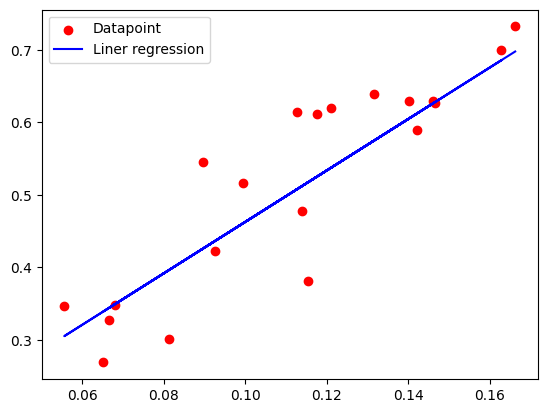

In [ ]:
# Plot the linear regression Model
plt.scatter(X_test[0:20],Y_test[0:20],color="Red",label="Datapoint")
plt.plot(X_test[0:20],Y_pred[0:20],color="Blue",label="Liner regression")
plt.legend()


In [ ]:
## Load the Height and weight  to indipendent and dependent variable

In [ ]:
df2=pd.read_csv("weight-height.csv")
X = df2['Height'].values.reshape(-1, 1)
X.shape
Y=df2["Weight"].values

In [ ]:
## Standardizes the features X and target variable y using Z-score normalization (also called Standardization).
X = (X - np.mean(X, axis=0)) / np.std(X, axis=0)
Y = (Y - np.mean(Y, axis=0)) / np.std(Y, axis=0)


In [ ]:
#add another feature to X corresponding to bias
X = np.hstack((np.ones((X.shape[0], 1)), X))
X

array([[ 1.        ,  1.75827913],
       [ 1.        ,  0.56277158],
       [ 1.        ,  1.82037531],
       ...,
       [ 1.        , -0.59704831],
       [ 1.        , 24.22511229],
       [ 1.        , -1.05110595]])

In [ ]:
#weight or parameter initialization
theta = np.zeros(X.shape[1])
iterations=1000
# Hyperparameters
learningrate=0.01
# Gradient Descent
mseh=[]
print(X.shape)
s=(y_pred - Y)
print(s.shape)
m=X.T
print(m.shape)

(10000, 2)
(10000,)
(2, 10000)


<img src="https://i.postimg.cc/wMYVXD65/1.png" alt="Image Description" width="500">

In [ ]:
for i in range(iterations):
    y_pred = np.dot(X, theta)
    mse = mean_squared_error(Y, y_pred)
    mseh.append(mse)
    print(f"Iteration {i+1}: MSE = {mse}")
    gradient = np.dot(X.T, (y_pred - Y)) / len(Y)
    theta -= learningrate * gradient

Iteration 1: MSE = 1.0
Iteration 2: MSE = 0.9858094192775753
Iteration 3: MSE = 0.9719012311115264
Iteration 4: MSE = 0.9582698158899821
Iteration 5: MSE = 0.9449096658313463
Iteration 6: MSE = 0.9318153827588777
Iteration 7: MSE = 0.9189816759195509
Iteration 8: MSE = 0.9064033598463269
Iteration 9: MSE = 0.8940753522629601
Iteration 10: MSE = 0.881992672030502
Iteration 11: MSE = 0.87015043713467
Iteration 12: MSE = 0.8585438627132651
Iteration 13: MSE = 0.8471682591228462
Iteration 14: MSE = 0.8360190300438765
Iteration 15: MSE = 0.8250916706235785
Iteration 16: MSE = 0.8143817656557442
Iteration 17: MSE = 0.80388498779677
Iteration 18: MSE = 0.7935970958171892
Iteration 19: MSE = 0.7835139328880021
Iteration 20: MSE = 0.773631424901106
Iteration 21: MSE = 0.7639455788231488
Iteration 22: MSE = 0.7544524810821432
Iteration 23: MSE = 0.7451482959861836
Iteration 24: MSE = 0.7360292641736336
Iteration 25: MSE = 0.7270917010941532
Iteration 26: MSE = 0.7183319955199547
Iteration 27: MS

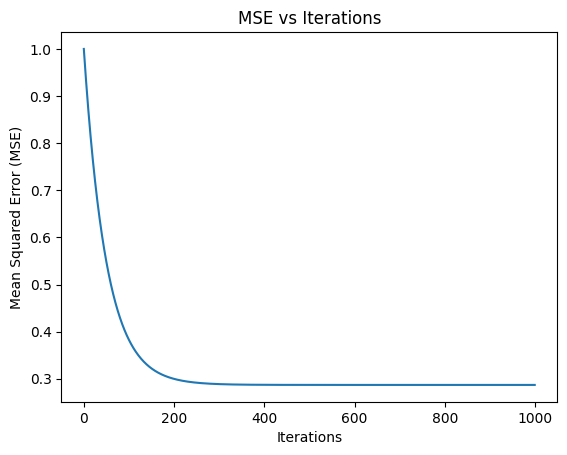

In [ ]:
# Plot the MSE over iterations
plt.plot(range(iterations), mseh)
plt.xlabel('Iterations')
plt.ylabel('Mean Squared Error (MSE)')
plt.title('MSE vs Iterations')
plt.show()

## You are required to fit a linear function on Food_delivery_times dataset
Description about the dataset: This dataset is designed for predicting food delivery times based on various influencing factors such as distance, weather, traffic conditions, and Preperation time.
1. Feature selection: Consider Food_delivery_time is effected by four features (attributes) given in the dataset, which are Distance_km, Preparation_Time_min, Traffic, Weather
2. Since Traffic, Weather are having categorical values, you need to convert them into numerical using the categorical encoding methods.
3. Now, fit a linear regression model considering Distance_km, Preparation_Time_min, Traffic, and Weather as independant variables and Delivery_Time_min as dependant varibal.


Note: In lab record, you can write the statements relevant to linear regression.